# Model Training & Evaluation

Notebook para entrenar y evaluar modelos de clasificación para la predicción de Churn.

**Modelos:** Logistic Regression, Random Forest, XGBoost, Gradient Boosting

**Métricas:** Recall, F1-Macro, AUC-ROC

**Validación:** Stratified K-Fold (5 folds)

**Optimización:** GridSearchCV

**Tracking:** MLflow

## 1. Configuración e Imports

In [1]:
import pandas as pd
import numpy as np
import os
import warnings
import mlflow
import mlflow.sklearn
import joblib
import xgboost
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("✓ Imports completados")

/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any 

✓ Imports completados


In [2]:

mlflow.set_tracking_uri("http://localhost:5001")
print("Tracking URI:", mlflow.get_tracking_uri())

exp = mlflow.set_experiment("churn_dev_proxy")
print("Experiment:", exp.name, exp.experiment_id)

Tracking URI: http://localhost:5001
Experiment: churn_dev_proxy 2


## 2. Carga de Datos

In [3]:
test_folder = '../data/resampled/original'
X_test = pd.read_csv(f'{test_folder}/X_test.csv')
y_test = pd.read_csv(f'{test_folder}/y_test.csv')['Churn']

print(f"Test set: {X_test.shape[0]} muestras, {X_test.shape[1]} features")
print(f"Distribución test:\n{y_test.value_counts()}")

Test set: 1407 muestras, 30 features
Distribución test:
Churn
0    1033
1     374
Name: count, dtype: int64


In [4]:
resampled_dir = '../data/resampled'
datasets = {}

for folder in sorted(os.listdir(resampled_dir)):
    path = os.path.join(resampled_dir, folder)
    if os.path.isdir(path) and 'X_train.csv' in os.listdir(path):
        X = pd.read_csv(f'{path}/X_train.csv')
        y = pd.read_csv(f'{path}/y_train.csv')['Churn']
        datasets[folder] = (X, y)
        print(f"✓ {folder}: {X.shape[0]} muestras, {X.shape[1]} features")

print(f"\nDatasets cargados: {list(datasets.keys())}")

✓ adasyn: 8292 muestras, 30 features
✓ original: 5625 muestras, 30 features
✓ random_over: 8260 muestras, 30 features
✓ random_under: 2990 muestras, 30 features
✓ smote: 8260 muestras, 30 features
✓ smote_enn: 4596 muestras, 30 features
✓ smote_tomek: 7506 muestras, 30 features

Datasets cargados: ['adasyn', 'original', 'random_over', 'random_under', 'smote', 'smote_enn', 'smote_tomek']


## 3. Comparación rápida con LazyPredict

LazyPredict entrena varios clasificadores con configuraciones base para obtener una referencia inicial antes de la optimización con GridSearchCV.

In [5]:
from lazypredict.Supervised import LazyClassifier

lazy_results = []

for dataset_name, (X_train, y_train) in datasets.items():
    lazy_classifier = LazyClassifier(
        verbose=0,
        ignore_warnings=True,
        custom_metric=None
    )
    lazy_models, _ = lazy_classifier.fit(X_train, X_test, y_train, y_test)
    lazy_models = lazy_models.reset_index().rename(columns={'index': 'Model'})
    lazy_models.insert(0, 'Dataset', dataset_name)
    lazy_results.append(lazy_models)

lazypredict_results = pd.concat(lazy_results, ignore_index=True)
lazypredict_results = lazypredict_results.sort_values(
    ['Dataset', 'F1 Score'], ascending=[True, False]
)

print('Resultados LazyPredict:')
print(lazypredict_results.to_string(index=False))

2026/09/24 12:25:43 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.
2026/09/24 12:25:43 INFO mlflow.tracking.fluent: Autologging successfully enabled for xgboost.
Registered model 'lazy_classifier_AdaBoostClassifier' already exists. Creating a new version of this model...
2026/09/24 12:25:48 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: lazy_classifier_AdaBoostClassifier, version 8
Created version '8' of model 'lazy_classifier_AdaBoostClassifier'.


🏃 View run LazyClassifier-AdaBoostClassifier at: http://localhost:5001/#/experiments/2/runs/bd3951f0a49b4159882cc708b9100c62
🧪 View experiment at: http://localhost:5001/#/experiments/2


Registered model 'lazy_classifier_BaggingClassifier' already exists. Creating a new version of this model...
2026/09/24 12:25:52 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: lazy_classifier_BaggingClassifier, version 8
Created version '8' of model 'lazy_classifier_BaggingClassifier'.


🏃 View run LazyClassifier-BaggingClassifier at: http://localhost:5001/#/experiments/2/runs/66405a8eaf7e47828b96b6f0b4cbc20a
🧪 View experiment at: http://localhost:5001/#/experiments/2


Registered model 'lazy_classifier_BernoulliNB' already exists. Creating a new version of this model...
2026/09/24 12:25:56 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: lazy_classifier_BernoulliNB, version 8
Created version '8' of model 'lazy_classifier_BernoulliNB'.


...

🏃 View run LazyClassifier-SVC at: http://localhost:5001/#/experiments/2/runs/1500e46a65cb49daae18f46fe50facfe
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run LazyClassifier-SelfTrainingClassifier at: http://localhost:5001/#/experiments/2/runs/e79178c6d34441f0988a7453ef5af8a3
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run LazyClassifier-StackingClassifier at: http://localhost:5001/#/experiments/2/runs/78efd500d0394375ab792d748c5410de
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run LazyClassifier-TunedThresholdClassifierCV at: http://localhost:5001/#/experiments/2/runs/b070820a6db14a7e8509ce0de4cb94ed
🧪 View experiment at: http://localhost:5001/#/experiments/2


Registered model 'lazy_classifier_XGBClassifier' already exists. Creating a new version of this model...
2026/09/24 12:40:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: lazy_classifier_XGBClassifier, version 14


🏃 View run LazyClassifier-XGBClassifier at: http://localhost:5001/#/experiments/2/runs/43f29fcd35be405ca5bffe0537197be2
🧪 View experiment at: http://localhost:5001/#/experiments/2
Resultados LazyPredict:
     Dataset                         Model  Accuracy  Balanced Accuracy  ROC AUC  F1 Score  Precision   Recall  Time Taken
      adasyn        CalibratedClassifierCV  0.779673           0.726285 0.818087  0.781465   0.783591 0.779673    2.145842
      adasyn                           SVC  0.769012           0.730965 0.801269  0.774351   0.782843 0.769012    8.563702
      adasyn            LogisticRegression  0.767591           0.736820 0.818340  0.774203   0.785964 0.767591    2.055546
      adasyn                     LinearSVC  0.764748           0.739148 0.818870  0.772334   0.786918 0.764748    2.071845
      adasyn        RandomForestClassifier  0.766169           0.717942 0.806340  0.769877   0.774929 0.766169    3.116294
      adasyn                 SGDClassifier  0.764748      

Created version '14' of model 'lazy_classifier_XGBClassifier'.


🏃 View run puzzled-mink-832 at: http://localhost:5001/#/experiments/2/runs/80b57424f8d249b89a0a61a0504833c7
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run awesome-fish-127 at: http://localhost:5001/#/experiments/2/runs/2ea94a26d45047d89be4e32f5527e48f
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run secretive-lamb-34 at: http://localhost:5001/#/experiments/2/runs/70c2890cb1dd4833938dd83c60129f1c
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run selective-smelt-695 at: http://localhost:5001/#/experiments/2/runs/44af605cfa794a92b0181e877d03d5bc
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run tasteful-snake-550 at: http://localhost:5001/#/experiments/2/runs/463615171d1f4de8b93b0aa326803a8c
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run amazing-steed-158 at: http://localhost:5001/#/experiments/2/runs/98f8801326ec429898d7135dbde51020
🧪 View experiment at: http://localhost:5001/#

## 3. Definición de Modelos e Hiperparámetros

In [6]:
from sklearn.naive_bayes import GaussianNB

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42),
    'NaiveBayes': GaussianNB(),
    'XGBoost': xgboost.XGBClassifier(random_state=42, eval_metric='logloss'),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}

print(f"Modelos definidos: {list(models.keys())}")

Modelos definidos: ['LogisticRegression', 'RandomForest', 'NaiveBayes', 'XGBoost', 'GradientBoosting']


In [7]:
param_grids = {
    'LogisticRegression': {
        'C': [0.01, 0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    'NaiveBayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    },
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.2]
    },
    'SVM': {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance'],
        'p': [1, 2]
    }
}

print("Hiperparámetros definidos para cada modelo")

Hiperparámetros definidos para cada modelo


## 4. Entrenamiento con GridSearchCV + MLflow

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

total = len(datasets) * len(models)
current = 0

for dataset_name, (X_train, y_train) in datasets.items():
    for model_name, model in models.items():
        current += 1
        print(f"\n{'='*60}")
        print(f"[{current}/{total}] Dataset: {dataset_name} | Modelo: {model_name}")
        print(f"{'='*60}")

        with mlflow.start_run(run_name=f"{dataset_name}_{model_name}"):
            mlflow.log_param("dataset", dataset_name)
            mlflow.log_param("model", model_name)
            mlflow.log_param("train_samples", X_train.shape[0])
            mlflow.log_param("features", X_train.shape[1])

            grid_search = GridSearchCV(
                model,
                param_grids[model_name],
                cv=cv,
                scoring='f1_macro',
                n_jobs=-1,
                verbose=0
            )
            grid_search.fit(X_train, y_train)

            mlflow.log_params(grid_search.best_params_)

            best_model = grid_search.best_estimator_
            y_pred = best_model.predict(X_test)
            y_proba = best_model.predict_proba(X_test)[:, 1]

            recall = recall_score(y_test, y_pred)
            f1 = f1_score(y_test, y_pred, average='macro')
            auc_roc = roc_auc_score(y_test, y_proba)

            mlflow.log_metric("recall", recall)
            mlflow.log_metric("f1_macro", f1)
            mlflow.log_metric("auc_roc", auc_roc)
            mlflow.log_metric("best_cv_score", grid_search.best_score_)

            artifact_name = f"{dataset_name}_{model_name}".replace(" ", "_")
            mlflow.sklearn.log_model(
                best_model,
                artifact_path="model",
                input_example=X_test.iloc[:2]
            )

            results.append({
                'Dataset': dataset_name,
                'Model': model_name,
                'Recall': recall,
                'F1-Macro': f1,
                'AUC-ROC': auc_roc,
                'Best_CV_F1_Macro': grid_search.best_score_,
                'Best_Params': str(grid_search.best_params_),
                'SVM': SVC(probability=True, random_state=42),
                'KNN': KNeighborsClassifier()
            })

            print(f"  ✓ Recall: {recall:.4f} | F1-Macro: {f1:.4f} | AUC-ROC: {auc_roc:.4f}")
            print(f"  ✓ Best CV F1-Macro: {grid_search.best_score_:.4f}")

print(f"\n{'='*60}")
print(f"✓ Entrenamiento completado: {len(results)} experimentos")
print(f"{'='*60}")


[1/35] Dataset: adasyn | Modelo: LogisticRegression


/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/nataliabernalgutierrez/Churn-Prediction/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarni

🏃 View run awesome-squid-144 at: http://localhost:5001/#/experiments/2/runs/df4e4027918e4c27bb3744f39d115eab
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run secretive-fawn-689 at: http://localhost:5001/#/experiments/2/runs/198d4ac23d2148008a592023d87c8df0
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run charming-calf-940 at: http://localhost:5001/#/experiments/2/runs/d68c7a51d92e4310b1d114101fca00ba
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run overjoyed-squid-702 at: http://localhost:5001/#/experiments/2/runs/9d6ff187ffa549238f29e15e3be39831
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run adorable-hen-631 at: http://localhost:5001/#/experiments/2/runs/c40ad50465244d58b2ec887268cff9f2
🧪 View experiment at: http://localhost:5001/#/experiments/2
  ✓ Recall: 0.6684 | F1-Macro: 0.7207 | AUC-ROC: 0.8191
  ✓ Best CV F1-Macro: 0.8259
🏃 View run adasyn_LogisticRegression at: http://localhost:5001/#/exp

2026/09/24 12:40:57 INFO mlflow.sklearn.utils: Logging the 5 best runs, 31 runs will be omitted.


🏃 View run dashing-owl-417 at: http://localhost:5001/#/experiments/2/runs/8607d91dec6c40ffb0ca96f26910a4bc
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run fortunate-calf-800 at: http://localhost:5001/#/experiments/2/runs/87b557eb4d2941148718c428d28d3603
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run exultant-grouse-663 at: http://localhost:5001/#/experiments/2/runs/e7253f11a19a4b1abdefa305d0cb74fc
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run likeable-stork-820 at: http://localhost:5001/#/experiments/2/runs/5490f6b5299d4fcba83bc3b943254ac5
🧪 View experiment at: http://localhost:5001/#/experiments/2
  ✓ Recall: 0.6417 | F1-Macro: 0.7159 | AUC-ROC: 0.8087
  ✓ Best CV F1-Macro: 0.8402
🏃 View run adasyn_RandomForest at: http://localhost:5001/#/experiments/2/runs/2c2b208f4f0c416c8d73be870bcf4ae4
🧪 View experiment at: http://localhost:5001/#/experiments/2

[3/35] Dataset: adasyn | Modelo: NaiveBayes


...

🏃 View run tasteful-fox-509 at: http://localhost:5001/#/experiments/2/runs/bae7ff26ddff493483e175621fa8af40
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run wise-sheep-852 at: http://localhost:5001/#/experiments/2/runs/b44d1190e36f4d3d9bc512f6da24f6d3
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run nosy-ape-385 at: http://localhost:5001/#/experiments/2/runs/b3b3a273b5c94f9fa4a2d5a2bb76104b
🧪 View experiment at: http://localhost:5001/#/experiments/2
  ✓ Recall: 0.7914 | F1-Macro: 0.6797 | AUC-ROC: 0.8027
  ✓ Best CV F1-Macro: 0.8070
🏃 View run smote_tomek_NaiveBayes at: http://localhost:5001/#/experiments/2/runs/65565890b40d4e9e9459140266e6d7e5
🧪 View experiment at: http://localhost:5001/#/experiments/2

[34/35] Dataset: smote_tomek | Modelo: XGBoost


2026/09/24 12:52:05 INFO mlflow.sklearn.utils: Logging the 5 best runs, 49 runs will be omitted.


🏃 View run judicious-foal-399 at: http://localhost:5001/#/experiments/2/runs/4ff253eed22449b5b21d7cb4d6a6e2dd
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run burly-dog-770 at: http://localhost:5001/#/experiments/2/runs/ddc46c2db81944bb953ec60da44beb9f
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run welcoming-turtle-945 at: http://localhost:5001/#/experiments/2/runs/6d8a1ff7968f49338d737c748d398501
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run sneaky-mole-951 at: http://localhost:5001/#/experiments/2/runs/5d0b813d57a540438c630a597415a070
🧪 View experiment at: http://localhost:5001/#/experiments/2
  ✓ Recall: 0.6230 | F1-Macro: 0.7149 | AUC-ROC: 0.8197
  ✓ Best CV F1-Macro: 0.8637
🏃 View run smote_tomek_XGBoost at: http://localhost:5001/#/experiments/2/runs/fa5b37df71364335bbcbcf855c2e0379
🧪 View experiment at: http://localhost:5001/#/experiments/2

[35/35] Dataset: smote_tomek | Modelo: GradientBoosting


2026/09/24 12:53:03 INFO mlflow.sklearn.utils: Logging the 5 best runs, 22 runs will be omitted.


🏃 View run masked-flea-827 at: http://localhost:5001/#/experiments/2/runs/d0c47c5d42d2475c9b4539ce52635d0b
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run abundant-bass-834 at: http://localhost:5001/#/experiments/2/runs/62698167529e46c5b2445bb7de43be86
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run wise-ant-181 at: http://localhost:5001/#/experiments/2/runs/f3db0a7fd9364c0095e23d435a715fff
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run amusing-bird-152 at: http://localhost:5001/#/experiments/2/runs/2de465968d7f4830b36d78a42724012c
🧪 View experiment at: http://localhost:5001/#/experiments/2
🏃 View run adorable-penguin-363 at: http://localhost:5001/#/experiments/2/runs/1fecf39836744879ac3fda2b69880a80
🧪 View experiment at: http://localhost:5001/#/experiments/2
  ✓ Recall: 0.5615 | F1-Macro: 0.6852 | AUC-ROC: 0.8017
  ✓ Best CV F1-Macro: 0.8647
🏃 View run smote_tomek_GradientBoosting at: http://localhost:5001/#/experim

## 5. Evaluación en Test Set

In [9]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Macro', ascending=False)

print("\n📊 Resultados ordenados por F1-Macro:")
print(results_df[['Dataset', 'Model', 'Recall', 'F1-Macro', 'AUC-ROC']].to_string(index=False))


📊 Resultados ordenados por F1-Macro:
     Dataset              Model   Recall  F1-Macro  AUC-ROC
    original LogisticRegression 0.574866  0.740469 0.836795
   smote_enn   GradientBoosting 0.732620  0.728162 0.818501
       smote LogisticRegression 0.663102  0.727163 0.825610
 random_over       RandomForest 0.601604  0.722603 0.815617
 smote_tomek LogisticRegression 0.657754  0.721711 0.828176
   smote_enn       RandomForest 0.735294  0.721284 0.823784
       smote       RandomForest 0.631016  0.720841 0.819583
      adasyn LogisticRegression 0.668449  0.720671 0.819064
       smote            XGBoost 0.633690  0.718618 0.819977
    original            XGBoost 0.521390  0.718130 0.839926
   smote_enn            XGBoost 0.716578  0.716261 0.824909
      adasyn       RandomForest 0.641711  0.715933 0.808734
    original   GradientBoosting 0.516043  0.714939 0.840072
 smote_tomek            XGBoost 0.622995  0.714897 0.819670
   smote_enn LogisticRegression 0.729947  0.714744 0.831575
 s

In [10]:
mlflow.set_experiment("churn_dev_proxy")

mlflow.sklearn.log_model(
    best_model,
    artifact_path="model",
    input_example=X_test.iloc[:2]
)

In [11]:
best = results_df.iloc[0]
print(f"\n🏆 Mejor modelo: {best['Model']} con dataset {best['Dataset']}")
print(f"   Recall:    {best['Recall']:.4f}")
print(f"   F1-Macro:  {best['F1-Macro']:.4f}")
print(f"   AUC-ROC:   {best['AUC-ROC']:.4f}")


🏆 Mejor modelo: LogisticRegression con dataset original
   Recall:    0.5749
   F1-Macro:  0.7405
   AUC-ROC:   0.8368


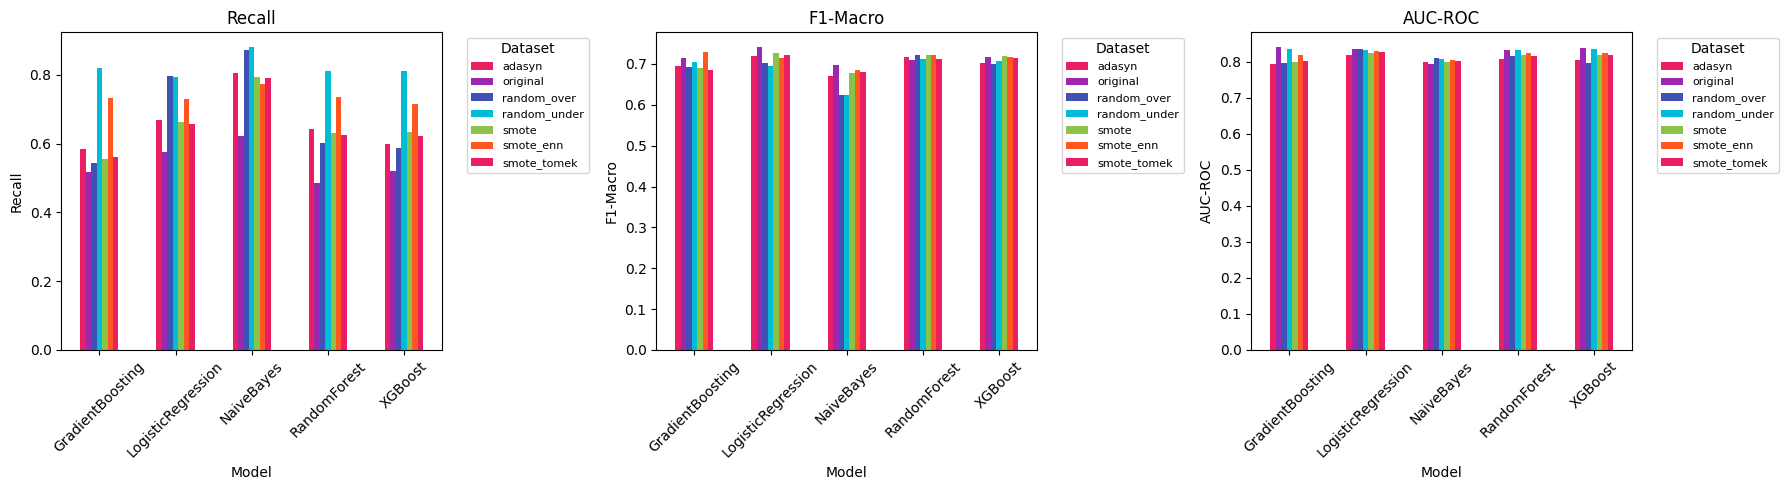

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Recall', 'F1-Macro', 'AUC-ROC']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for idx, metric in enumerate(metrics):
    pivot = results_df.pivot_table(index='Model', columns='Dataset', values=metric)
    pivot.plot(kind='bar', ax=axes[idx], color=['#E91E63', '#9C27B0', '#3F51B5', '#00BCD4', '#8BC34A', '#FF5722'])
    axes[idx].set_title(metric)
    axes[idx].set_ylabel(metric)
    axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].legend(title='Dataset', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

## 6. Optimización de Threshold

In [13]:
best_model_name = best['Model']
best_dataset_name = best['Dataset']
best_params_str = best['Best_Params']

import ast
best_params = ast.literal_eval(best_params_str)

X_train_best, y_train_best = datasets[best_dataset_name]

final_model = models[best_model_name].set_params(**best_params)
final_model.fit(X_train_best, y_train_best)

y_proba = final_model.predict_proba(X_test)[:, 1]

print(f"Modelo final: {best_model_name} (Dataset: {best_dataset_name})")
print(f"Parámetros: {best_params}")

Modelo final: LogisticRegression (Dataset: original)
Parámetros: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}


In [14]:
thresholds = np.arange(0.1, 0.9, 0.05)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        'Threshold': round(t, 2),
        'Recall': recall_score(y_test, y_pred_t),
        'F1-Macro': f1_score(y_test, y_pred_t, average='macro'),
        'Predictions_Pos': y_pred_t.sum()
    })

threshold_df = pd.DataFrame(threshold_results)
print("\n📊 Métricas por Threshold:")
print(threshold_df.to_string(index=False))


📊 Métricas por Threshold:
 Threshold   Recall  F1-Macro  Predictions_Pos
      0.10 0.946524  0.601368              889
      0.15 0.909091  0.638998              800
      0.20 0.868984  0.672468              713
      0.25 0.820856  0.696762              632
      0.30 0.759358  0.711886              552
      0.35 0.719251  0.723804              496
      0.40 0.681818  0.734582              444
      0.45 0.631016  0.739049              388
      0.50 0.574866  0.740469              330
      0.55 0.483957  0.716079              270
      0.60 0.390374  0.682490              213
      0.65 0.283422  0.634803              149
      0.70 0.163102  0.563485               81
      0.75 0.069519  0.490534               32
      0.80 0.018717  0.442667                8
      0.85 0.000000  0.423361                0


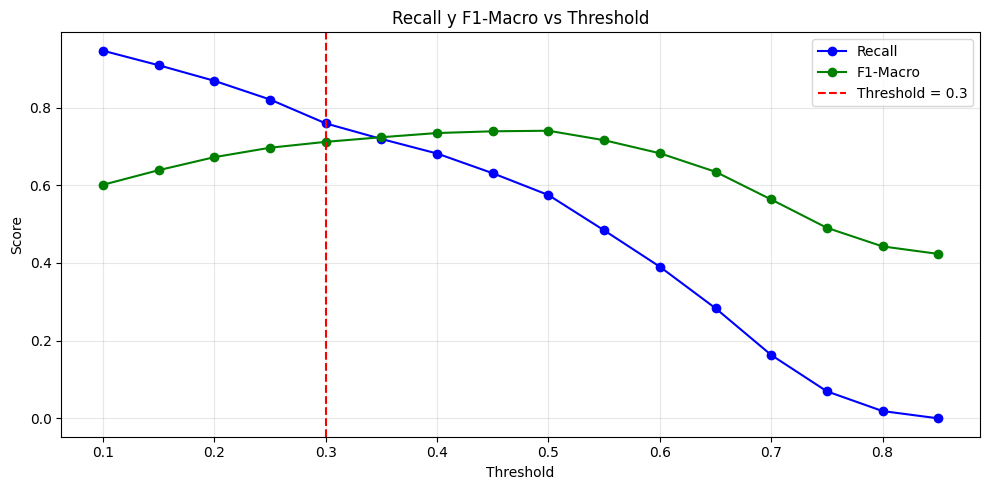

In [15]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(threshold_df['Threshold'], threshold_df['Recall'], 'b-o', label='Recall')
ax1.plot(threshold_df['Threshold'], threshold_df['F1-Macro'], 'g-o', label='F1-Macro')
ax1.set_xlabel('Threshold')
ax1.set_ylabel('Score')
ax1.axvline(x=0.3, color='r', linestyle='--', label='Threshold = 0.3')
ax1.legend(loc='upper right')
ax1.set_title('Recall y F1-Macro vs Threshold')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
THRESHOLD = 0.3
y_pred_final = (y_proba >= THRESHOLD).astype(int)

print(f"\n📊 Resultados con Threshold = {THRESHOLD}")
print(f"{'='*40}")
print(f"Recall:    {recall_score(y_test, y_pred_final):.4f}")
print(f"F1-Macro:  {f1_score(y_test, y_pred_final, average='macro'):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_final))
print(f"\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_final, digits=4))


📊 Resultados con Threshold = 0.3
Recall:    0.7594
F1-Macro:  0.7119
AUC-ROC:   0.8368

Matriz de Confusión:
[[765 268]
 [ 90 284]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0     0.8947    0.7406    0.8104      1033
           1     0.5145    0.7594    0.6134       374

    accuracy                         0.7456      1407
   macro avg     0.7046    0.7500    0.7119      1407
weighted avg     0.7937    0.7456    0.7580      1407



## 7. Guardar Resultados

In [17]:
os.makedirs('../data/results', exist_ok=True)

results_df.to_csv('../data/results/model_training_results.csv', index=False)
print("✓ Resultados guardados en model_training_results.csv")

✓ Resultados guardados en model_training_results.csv


In [18]:
joblib.dump(final_model, f'../data/results/best_model_{best_model_name}.joblib')
print(f"✓ Mejor modelo guardado: best_model_{best_model_name}.joblib")

✓ Mejor modelo guardado: best_model_LogisticRegression.joblib


In [19]:
print(f"\n{'='*60}")
print(f"✓ PIPELINE COMPLETADO")
print(f"{'='*60}")
print(f"\nArchivos generados:")
print(f"  - ../data/results/model_training_results.csv")
print(f"  - ../data/results/best_model_{best_model_name}.joblib")
print(f"  - mlruns/ (MLflow experiments)")
print(f"\nPara ver MLflow UI ejecuta:")
print(f"  mlflow ui")


✓ PIPELINE COMPLETADO

Archivos generados:
  - ../data/results/model_training_results.csv
  - ../data/results/best_model_LogisticRegression.joblib
  - mlruns/ (MLflow experiments)

Para ver MLflow UI ejecuta:
  mlflow ui
